In [1]:
import ee
import geemap

ee.Initialize()

print("Earth Engine Initialized")

Earth Engine Initialized


In [2]:
delhi = ee.Geometry.Rectangle(
    [76.84, 28.40, 77.35, 28.90]
)

print("Delhi region loaded")

Delhi region loaded


In [3]:
years = [2018, 2020, 2024]

images = {}

for year in years:
    image = (
        ee.ImageCollection(
            'COPERNICUS/S2_SR_HARMONIZED'
        )
        .filterBounds(delhi)
        .filterDate(
            f'{year}-01-01',
            f'{year}-12-31'
        )
        .filter(
            ee.Filter.lt(
                'CLOUDY_PIXEL_PERCENTAGE',
                10
            )
        )
        .median()
    )

    images[year] = image

print("Images loaded")

Images loaded


In [4]:
rgb_vis = {
    'min':0,
    'max':3000,
    'bands':['B4','B3','B2']
}

Map = geemap.Map()

Map.centerObject(
    delhi,
    10
)

Map.addLayer(
    images[2024],
    rgb_vis,
    "Delhi 2024"
)

Map

Map(center=[28.650040090919784, 77.0950000000002], controls=(WidgetControl(options=['position', 'transparent_b…

In [5]:
worldcover = ee.ImageCollection(
    "ESA/WorldCover/v200"
).first()

Map = geemap.Map()

Map.centerObject(
    delhi,
    10
)

Map.addLayer(
    worldcover,
    {},
    "WorldCover"
)

Map

Map(center=[28.650040090919784, 77.0950000000002], controls=(WidgetControl(options=['position', 'transparent_b…

In [9]:
# Smaller central Delhi region
small_delhi = ee.Geometry.Rectangle(
    [77.00, 28.50, 77.25, 28.75]
)

image_export = (
    images[2024]
    .select(['B4','B3','B2'])
    .clip(small_delhi)
)

geemap.ee_export_image(
    image_export,
    filename='../data/raw/delhi_2024_rgb.tif',
    scale=50,        # coarser resolution
    region=small_delhi
)

print("Export complete")

Generating URL ...
Please wait ...
Data downloaded to d:\Projects\GeoVisionAI\data\raw\delhi_2024_rgb.tif
Export complete


Shape: (3, 557, 557)


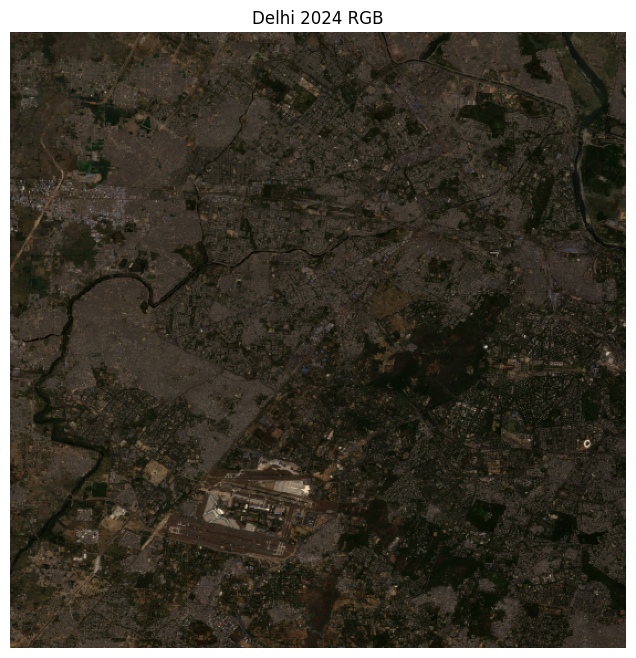

In [12]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

file_path = "../data/raw/delhi_2024_rgb.tif"

with rasterio.open(file_path) as src:
    img = src.read()

print("Shape:", img.shape)

# Convert to (height,width,channels)
img = img.transpose(1,2,0)

# Normalize values
img = img.astype(np.float32)
img = (img - img.min()) / (img.max() - img.min())

plt.figure(figsize=(8,8))

plt.imshow(img)

plt.title("Delhi 2024 RGB")
plt.axis('off')

plt.show()

In [13]:
# Load ESA WorldCover labels
worldcover = ee.ImageCollection(
    "ESA/WorldCover/v200"
).first()

Map = geemap.Map()

Map.centerObject(
    delhi,
    10
)

Map.addLayer(
    worldcover,
    {},
    "WorldCover"
)

Map

Map(center=[28.650040090919124, 77.0950000000002], controls=(WidgetControl(options=['position', 'transparent_b…

In [14]:
label_export = (
    worldcover
    .clip(delhi)
)

geemap.ee_export_image(
    label_export,
    filename='../data/raw/delhi_labels.tif',
    scale=50,
    region=delhi
)

print("Labels exported")

Generating URL ...
Please wait ...
Data downloaded to d:\Projects\GeoVisionAI\data\raw\delhi_labels.tif
Labels exported


Shape: (1115, 1137)


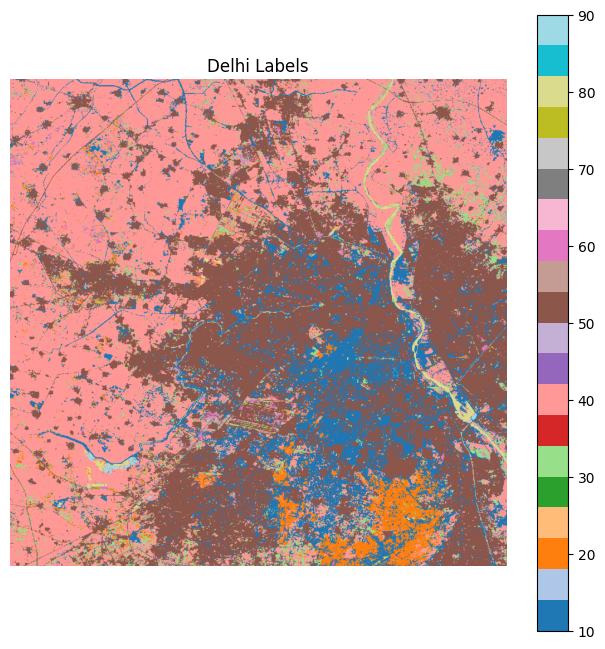

In [15]:
import rasterio
import matplotlib.pyplot as plt

label_path = "../data/raw/delhi_labels.tif"

with rasterio.open(label_path) as src:
    labels = src.read(1)

print("Shape:", labels.shape)

plt.figure(figsize=(8,8))

plt.imshow(
    labels,
    cmap='tab20'
)

plt.colorbar()

plt.title(
    "Delhi Labels"
)

plt.axis('off')

plt.show()

In [16]:
import numpy as np

print(
    np.unique(labels)
)

[10 20 30 40 50 60 80 90]


In [17]:
# Remap ESA classes

mapping = {
    10:1,
    20:1,
    30:1,

    40:2,

    50:3,

    60:4,

    80:5,
    90:5
}

labels_simple = np.copy(labels)

for old,new in mapping.items():
    labels_simple[
        labels==old
    ] = new


print(
    np.unique(
        labels_simple
    )
)

[1 2 3 4 5]


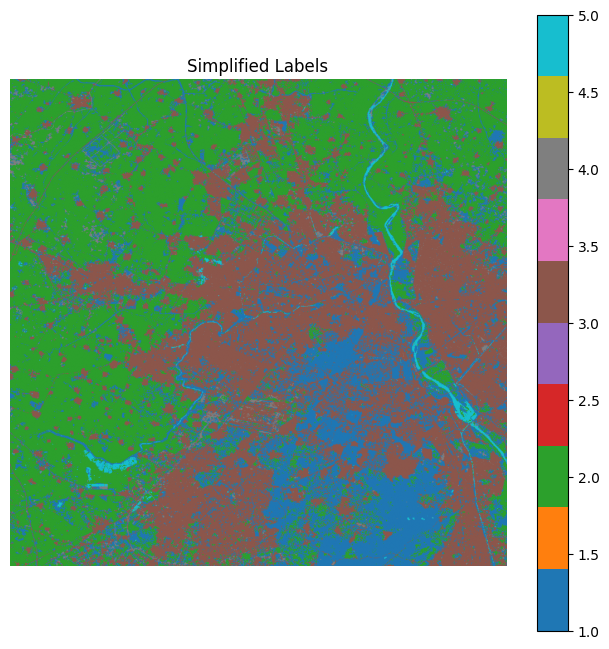

In [18]:
plt.figure(
    figsize=(8,8)
)

plt.imshow(
    labels_simple,
    cmap='tab10'
)

plt.colorbar()

plt.title(
    "Simplified Labels"
)

plt.axis('off')

plt.show()

In [19]:
np.unique(labels_simple)

array([1, 2, 3, 4, 5], dtype=uint8)

In [20]:
tile_size = 128

image_tiles = []
mask_tiles = []

for i in range(
    0,
    img.shape[0]-tile_size,
    tile_size
):
    for j in range(
        0,
        img.shape[1]-tile_size,
        tile_size
    ):

        image_tile = img[
            i:i+tile_size,
            j:j+tile_size
        ]

        mask_tile = labels_simple[
            i:i+tile_size,
            j:j+tile_size
        ]

        image_tiles.append(
            image_tile
        )

        mask_tiles.append(
            mask_tile
        )


print(
    "Image tiles:",
    len(image_tiles)
)

print(
    "Mask tiles:",
    len(mask_tiles)
)

Image tiles: 16
Mask tiles: 16
